# From delivered tables to the adaptation corpus

This notebook checks what preprocessing kept, examines the task targets, and explains the fixed dataset partitions and sampling weights. It describes inputs, not experimental outcomes.

The four held-out dataset partitions are different from the five outer evaluation folds inside each held-out dataset. Every table is held out once across the four partitions. Related sources and overlapping training corpora limit independence.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from IPython.display import display
from src.visualize import style
from src.visualize.figures import FigureSaver
from src.visualize import campaign as cp
from src.data.dataset_names import display_frame
from src.visualize.inputs import analysis_root
style.apply()
sink = FigureSaver('00_general/02_processed_data')
report = cp.NotebookReport('From delivered tables to the adaptation corpus')
from src.visualize import corpus as cv


## 1. Processed inventory

Shapes and missingness are measured from the processed files. Unknown files remain unknown. Predictor counts exclude targets.

In [2]:
data = cv.processed_inventory()
display(data[['track','dataset_id','rows','features','missing']])
report.add('1. Processed inventory', cv.inventory_summary(data, 'Processed'))

,track,dataset_id,rows,features,missing
0,pd,0001.gmsc,150000,10,0.022437
1,pd,0002.taiwan_creditcard,30000,23,0.000000
2,pd,0003.vehicle_loan,233154,33,0.000996
3,pd,0004.lendingclub,9578,13,0.000000
4,pd,0005.myhom,7000,8,0.004375
5,pd,0006.hackerearth,532428,36,0.067109
6,pd,0007.cobranded,80000,47,0.188361
7,pd,0008.german,999,20,0.000000
8,pd,PropPD1,100000,16,0.060931
9,pd,0010.thomas,1225,14,0.000000


## 2. What preprocessing changed

Registration includes documented dataset-specific corrections. Compare processed shape with that registered input, rather than silently mixing it with unmodified raw-file dimensions.

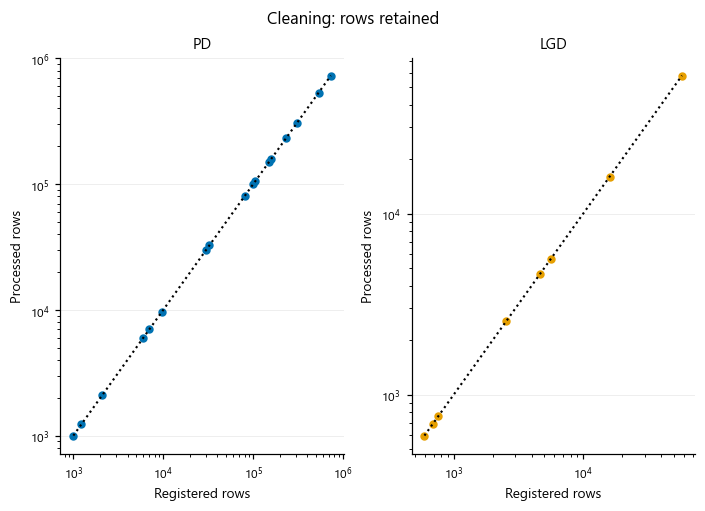

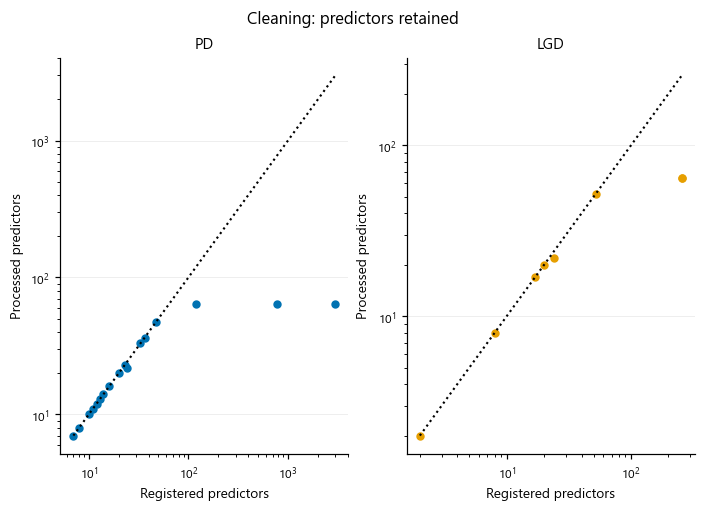

In [3]:
cp.show(sink, cv.plot_cleaning(data))
report.add('2. Cleaning changes', data.groupby('track')[['raw_rows','post_rows','raw_features','post_features']].sum().to_string())

## 3. The actual training inputs

Read the geometry first, then dataset-level missingness. Pagination keeps labels readable at the final A4 width.

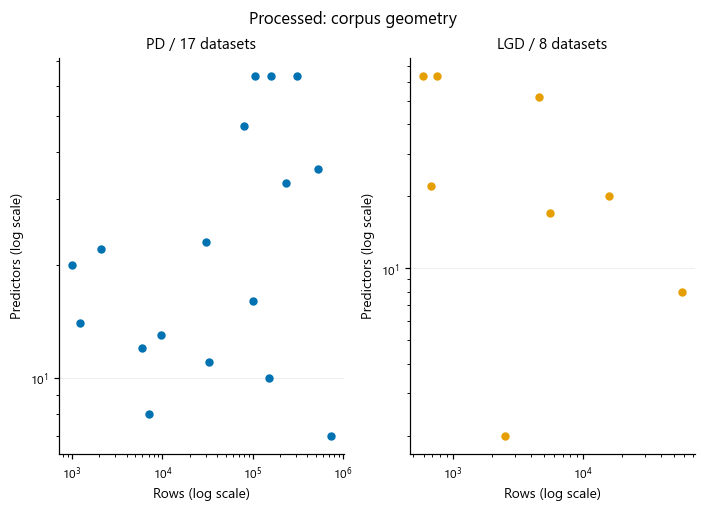

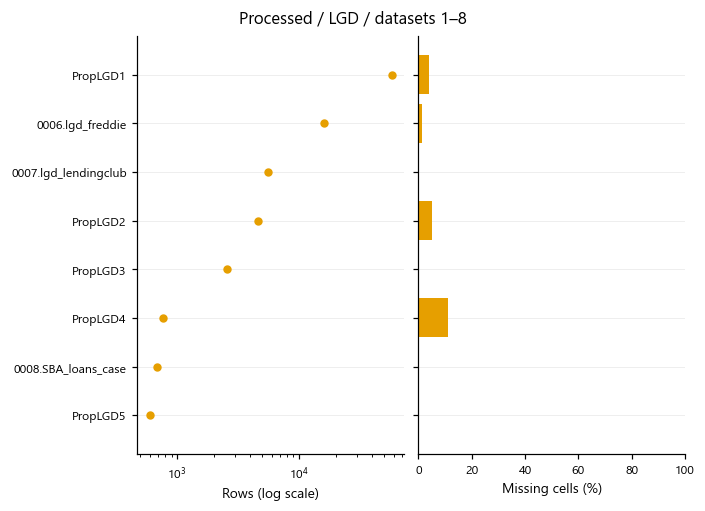

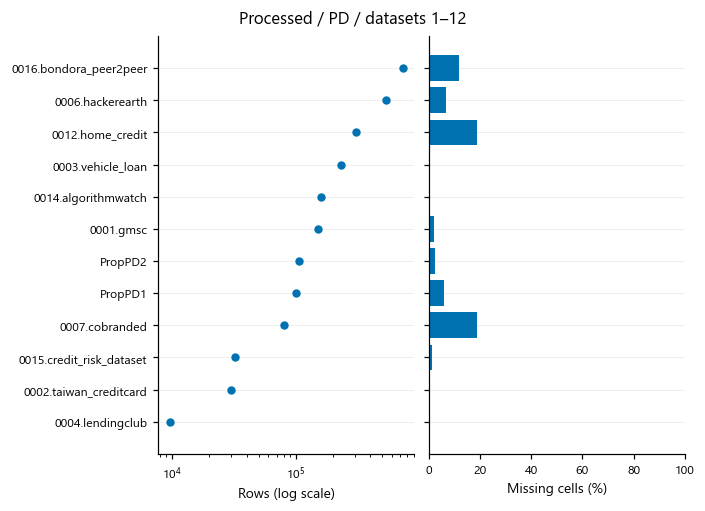

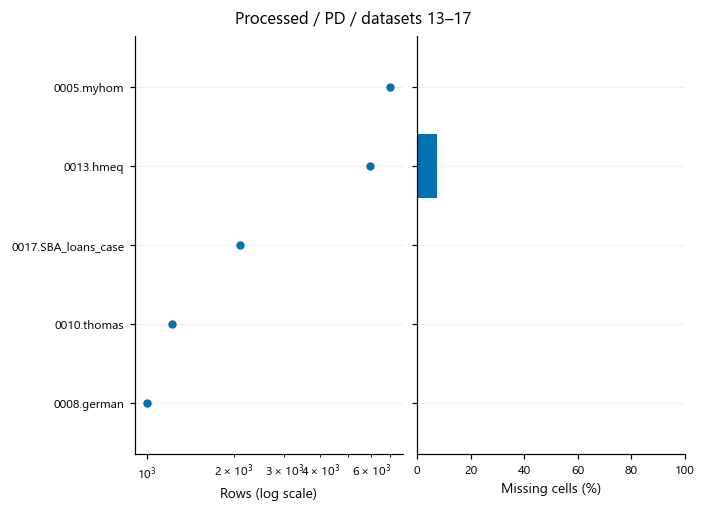

In [4]:
cp.show(sink, cv.plot_geometry(data, 'Processed'))
cp.show(sink, cv.plot_profiles(data, 'Processed'))
report.add('3. Training-input quality', data.groupby('track')[['rows','features','missing']].agg(['median','max']).to_string())

## 4. Targets and heterogeneous difficulty

PD class imbalance is shown table by table. LGD histograms give each dataset its own panel; targets are not pooled or clipped. Differences in target scale motivate within-dataset normalized RMSE effects later.

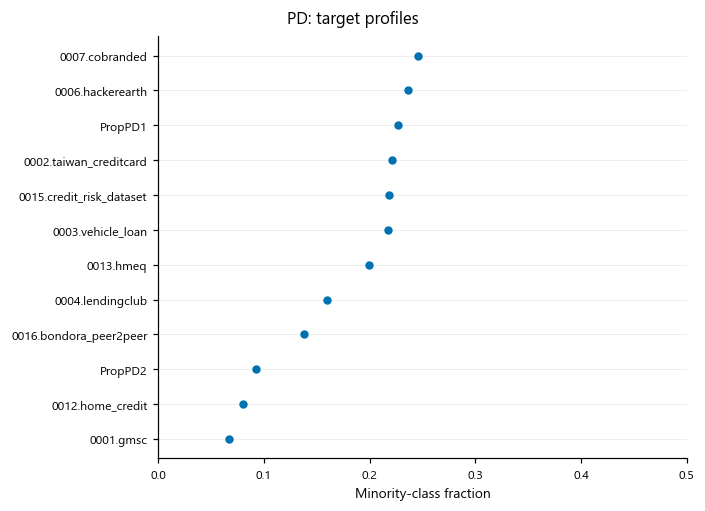

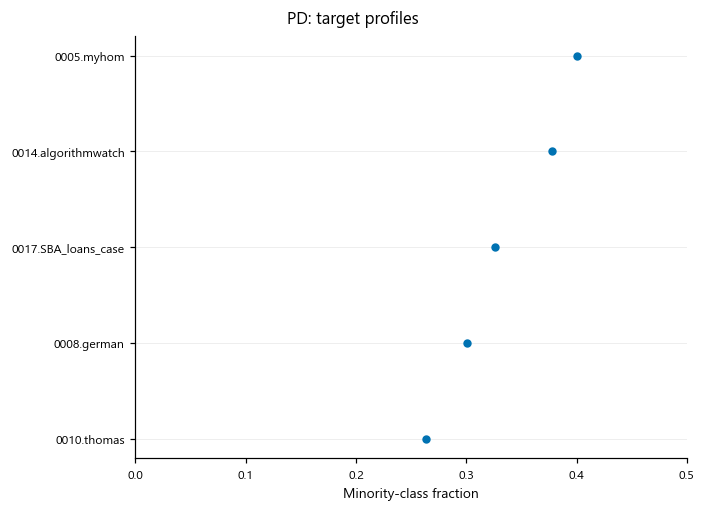

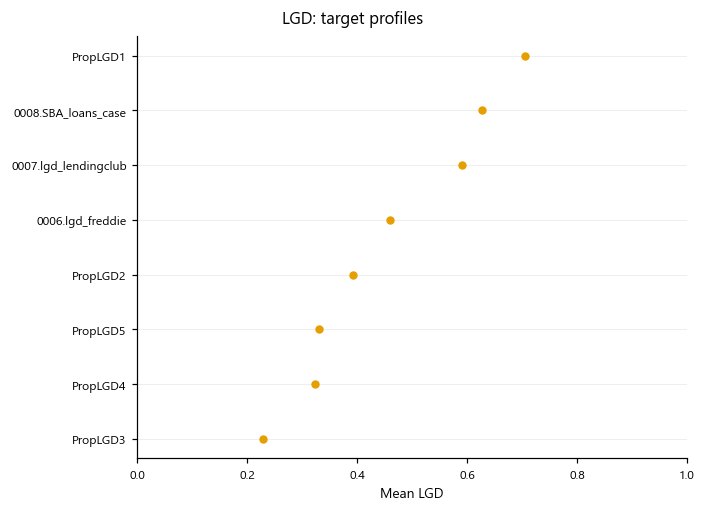

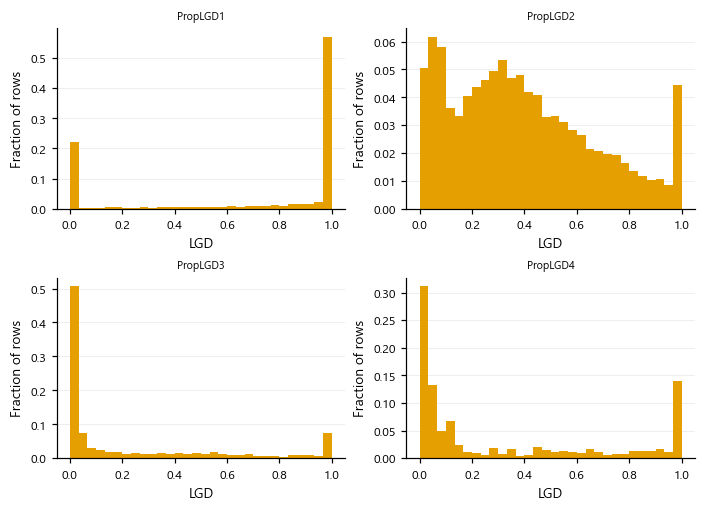

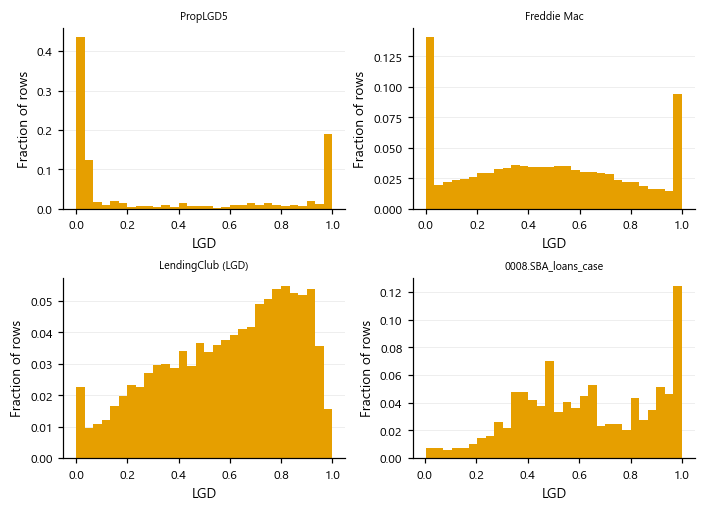

In [5]:
cp.show(sink, cv.plot_target_profiles(data))
cp.show(sink, cv.plot_lgd_distributions())
report.add('4. Target profiles', data.groupby('track')[['minority_class_ratio','target_mean','target_std']].agg(['count','median','min','max']).to_string())

## 5. Which datasets are held out together?

One filled cell per dataset identifies its held-out partition. Training uses the complement. This map is shared by experiments 1, 2 and 3; operational pilots use only the first partition.

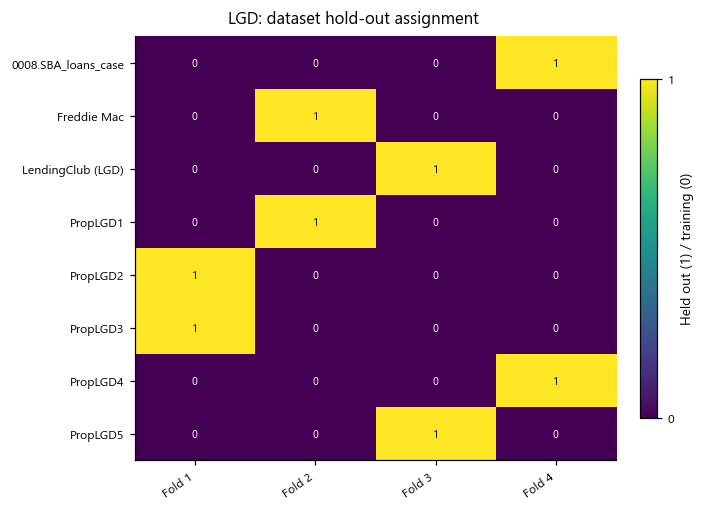

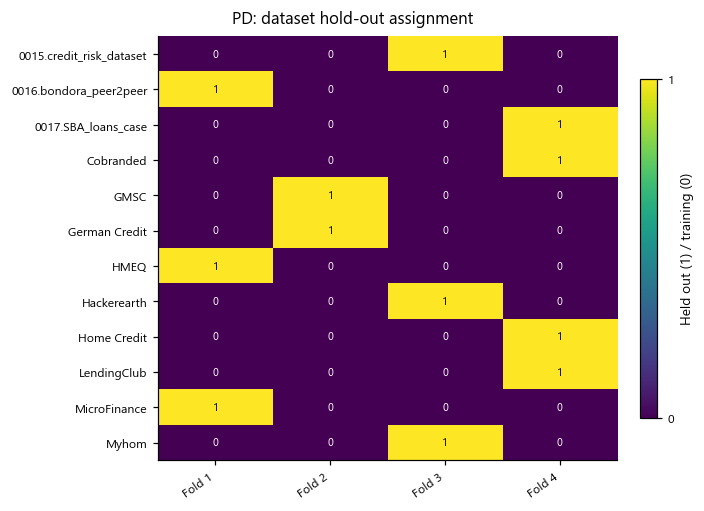

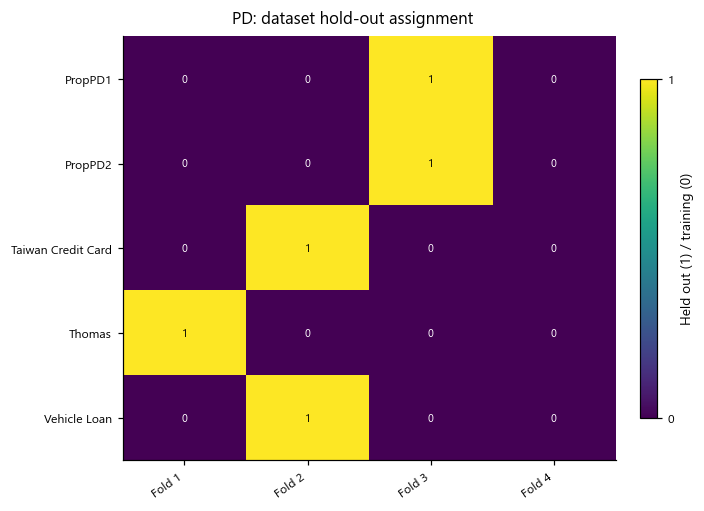

In [6]:
partitions = cv.partition_table()
cp.show(sink, cv.plot_partitions(partitions))
report.add('5. Dataset partitions', partitions.groupby(['track','fold']).size().rename('held_out_tables').to_string())

## 6. Why sampling deserves its own experiment

The illustrative 10,000-row cap makes the distinction visible: one_sample and accumulate give one update per table visit; full_pass gives one update per disjoint chunk. Real caps differ by base, and a fixed update budget can stop before a traversal finishes.

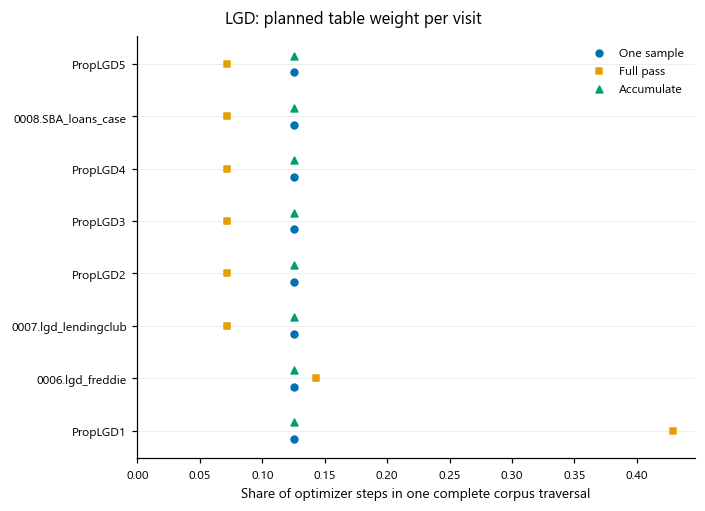

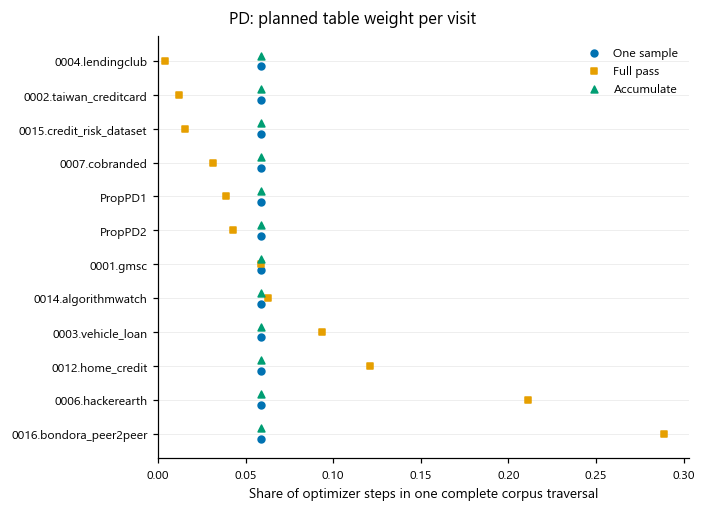

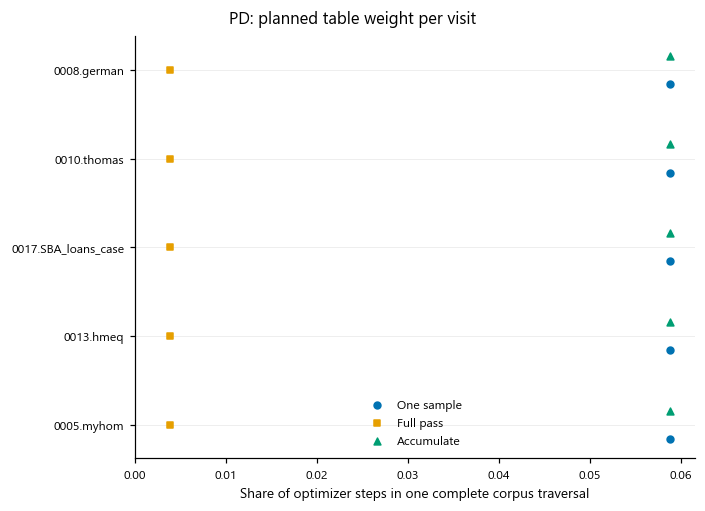

In [7]:
exposure = cv.planned_exposure(data)
cp.show(sink, cv.plot_exposure(exposure))
report.add('6. Planned exposure illustration', exposure.groupby('track')[['chunks','rows']].sum().to_string() + '\nIllustration only: 10,000-row cap, all tables, no numerical skips.')

## 7. Quality flags and interpretation limits

Flags identify tables for inspection. They do not authorize changing the corpus after viewing experimental effects. Raw observations, processed inputs and held-out evaluation remain distinct.

In [8]:
from src.data.exploration import find_anomalous_datasets
anomalies = display_frame(find_anomalous_datasets())
display(anomalies)
report.add('7. Quality flags', anomalies.to_string(index=False) if len(anomalies) else 'No configured anomaly flags.')

""


## Summary

The following text repeats the sections in order. It is included verbatim in `All_Results.md`.

In [9]:
print(report.summary(sink))

From delivered tables to the adaptation corpus

1. Processed inventory
Processed: 25/25 registered datasets available.
       datasets     rows  min_rows  max_rows  max_features
track                                                     
lgd           8    88785       594     57932            64
pd           17  2486885       999    730176            64

2. Cleaning changes
       raw_rows  post_rows  raw_features  post_features
track                                                  
lgd       88785      88785           634            249
pd      2486885    2486885          4150            464

3. Training-input quality
          rows         features       missing          
        median     max   median max    median       max
track                                                  
lgd     3591.0   57932     21.0  64  0.007520  0.110523
pd     80000.0  730176     20.0  64  0.011197  0.188361

4. Target profiles
      minority_class_ratio                      target_mean              